In [1]:
from hda import Client
from bmc.cube import wekeo # Or however you import your module

c = Client()
wekeo_cube = wekeo.wekeo_cube()

microlake_recipe = wekeo_cube.generate_cube_recipe("../../config/level2/micro_lake.yaml")

# Trigger using explicit keyword arguments
generated_cogs = wekeo_cube.build_wekeo_datalake(
    recipe=microlake_recipe, 
    wekeo_client=c
)

Attempting to load configuration from: ../../config/level2/micro_lake.yaml


In [13]:
import sys
print(sys.executable)

c:\Users\niels\anaconda3\envs\BmC\python.exe


In [2]:
generated_cogs

['.\\micro_lake\\GRA\\Grassland\\coverage\\Grassland_2018_EEA_100m_Non_grassland.tif',
 '.\\micro_lake\\GRA\\Grassland\\coverage\\Grassland_2018_EEA_100m_Grassland.tif',
 '.\\micro_lake\\GRA\\Grassland\\coverage\\Grassland_2019_EEA_100m_Non_grassland.tif',
 '.\\micro_lake\\GRA\\Grassland\\coverage\\Grassland_2019_EEA_100m_Grassland.tif',
 '.\\micro_lake\\GRA\\Grassland\\coverage\\Grassland_2020_EEA_100m_Non_grassland.tif',
 '.\\micro_lake\\GRA\\Grassland\\coverage\\Grassland_2020_EEA_100m_Grassland.tif',
 '.\\micro_lake\\TCF\\Tree_Cover_Density\\average\\Tree_Cover_Density_2018_EEA_100m_average.tif',
 '.\\micro_lake\\TCF\\Tree_Cover_Density\\max\\Tree_Cover_Density_2018_EEA_100m_max.tif',
 '.\\micro_lake\\TCF\\Tree_Cover_Density\\min\\Tree_Cover_Density_2018_EEA_100m_min.tif',
 '.\\micro_lake\\TCF\\Tree_Cover_Density\\rms\\Tree_Cover_Density_2018_EEA_100m_rms.tif',
 '.\\micro_lake\\TCF\\Tree_Cover_Density\\average\\Tree_Cover_Density_2019_EEA_100m_average.tif',
 '.\\micro_lake\\TCF\\Tr

In [3]:
import os
import xarray as xr
import rioxarray

def run_datalake_qa(base_dir: str, year: int = 2018, grid: str = "EEA_100m"):
    print(f"--- Starting QA Validation for {base_dir} ({year}) ---")
    
    # Define exact paths based on your output
    tcd_avg_path = os.path.join(base_dir, "TCF", "Tree_Cover_Density", "average", f"Tree_Cover_Density_{year}_{grid}_average.tif")
    tcd_max_path = os.path.join(base_dir, "TCF", "Tree_Cover_Density", "max", f"Tree_Cover_Density_{year}_{grid}_max.tif")
    tcd_min_path = os.path.join(base_dir, "TCF", "Tree_Cover_Density", "min", f"Tree_Cover_Density_{year}_{grid}_min.tif")
    
    ft_broad_path = os.path.join(base_dir, "TCF", "Forest_Type", "coverage", f"Forest_Type_{year}_{grid}_Broadleaved_forest.tif")
    ft_conif_path = os.path.join(base_dir, "TCF", "Forest_Type", "coverage", f"Forest_Type_{year}_{grid}_Coniferous_forest.tif")
    gra_frac_path = os.path.join(base_dir, "GRA", "Grassland", "coverage", f"Grassland_{year}_{grid}_Grassland.tif")

    def load_da(path):
        if not os.path.exists(path):
            print(f"  [!] Missing file: {path}")
            return None
        return rioxarray.open_rasterio(path, masked=True).squeeze()

    # Load into memory
    tcd_avg, tcd_max, tcd_min = load_da(tcd_avg_path), load_da(tcd_max_path), load_da(tcd_min_path)
    broad_frac, conif_frac, gra_frac = load_da(ft_broad_path), load_da(ft_conif_path), load_da(gra_frac_path)

    # TEST 1: Min <= Average <= Max
    print("\n[TEST 1] Continuous Mathematics (Tree Cover Density)")
    if tcd_avg is not None and tcd_max is not None:
        avg_gt_max = (tcd_avg > (tcd_max + 0.0001)).sum().item()
        min_gt_avg = (tcd_min > (tcd_avg + 0.0001)).sum().item()
        print(f"  -> Average > Max: {avg_gt_max} " + ("✅" if avg_gt_max == 0 else "❌"))
        print(f"  -> Min > Average: {min_gt_avg} " + ("✅" if min_gt_avg == 0 else "❌"))

    # TEST 2: 0.0 to 1.0 Bounds
    print("\n[TEST 2] Fractional Boundaries (0 to 1)")
    for name, da in [("Broadleaved", broad_frac), ("Coniferous", conif_frac), ("Grassland", gra_frac)]:
        if da is not None:
            under_zero, over_one = (da < -0.0001).sum().item(), (da > 1.0001).sum().item()
            print(f"  -> {name}: {under_zero} pixels < 0 | {over_one} pixels > 1 " + ("✅" if (under_zero == 0 and over_one == 0) else "❌"))

    # TEST 3: Mutually Exclusive Summation
    print("\n[TEST 3] Mutually Exclusive Summation (Forest Types)")
    if broad_frac is not None and conif_frac is not None:
        total_forest = broad_frac.fillna(0) + conif_frac.fillna(0)
        valid_mask = broad_frac.notnull() | conif_frac.notnull()
        over_100 = ((total_forest > 1.0001) & valid_mask).sum().item()
        print(f"  -> (Broadleaved + Coniferous) > 100%: {over_100} " + ("✅" if over_100 == 0 else "❌"))

    # TEST 4: Cross-Layer Logic
    print("\n[TEST 4] Cross-Layer Ecological Logic")
    if tcd_max is not None and broad_frac is not None and conif_frac is not None:
        total_forest = broad_frac.fillna(0) + conif_frac.fillna(0)
        impossible_forests = ((total_forest > 0.01) & (tcd_max == 0)).sum().item()
        print(f"  -> 0% Max Tree Cover but > 0% Forest Type: {impossible_forests} " + ("✅" if impossible_forests == 0 else "❌"))

# Execute the test!
run_datalake_qa(base_dir="micro_lake", year=2018, grid="EEA_100m")

--- Starting QA Validation for micro_lake (2018) ---

[TEST 1] Continuous Mathematics (Tree Cover Density)
  -> Average > Max: 0 ✅
  -> Min > Average: 0 ✅

[TEST 2] Fractional Boundaries (0 to 1)
  -> Broadleaved: 0 pixels < 0 | 0 pixels > 1 ✅
  -> Coniferous: 0 pixels < 0 | 0 pixels > 1 ✅
  -> Grassland: 0 pixels < 0 | 0 pixels > 1 ✅

[TEST 3] Mutually Exclusive Summation (Forest Types)
  -> (Broadleaved + Coniferous) > 100%: 0 ✅

[TEST 4] Cross-Layer Ecological Logic
  -> 0% Max Tree Cover but > 0% Forest Type: 0 ✅


In [10]:
import os
from pathlib import Path
import xarray as xr
import rioxarray
import numpy as np

def run_global_datalake_qa(base_dir: str, tolerance: float = 0.0001):
    """
    Dynamically crawls a structured data lake and performs strict mathematical 
    and ecological QA validations on all detected continuous and categorical datasets.
    """
    base_path = Path(base_dir)
    print(f"=== Initiating Global QA Sweep on: {base_path.absolute()} ===\n")
    
    if not base_path.exists():
        print(f"[!] Target directory does not exist: {base_dir}")
        return

    # 1. Discover and Group Data by Product and Year
    lake_catalog = {}
    
    for tif_path in base_path.rglob("*.tif"):
        parts = tif_path.parts
        if len(parts) < 4: continue
        
        category = parts[-4]
        product = parts[-3]
        aggregation = parts[-2]
        
        import re
        year_match = re.search(r'(19\d{2}|20\d{2})', tif_path.name)
        year = int(year_match.group(1)) if year_match else "AllYears"
        
        if category not in lake_catalog: lake_catalog[category] = {}
        if product not in lake_catalog[category]: lake_catalog[category][product] = {}
        if year not in lake_catalog[category][product]: lake_catalog[category][product][year] = {}
        
        if aggregation == 'coverage':
            if 'coverage' not in lake_catalog[category][product][year]:
                lake_catalog[category][product][year]['coverage'] = []
            lake_catalog[category][product][year]['coverage'].append(tif_path)
        else:
            lake_catalog[category][product][year][aggregation] = tif_path

    def load_da(path):
        return rioxarray.open_rasterio(path, masked=True, chunks={'x': 2048, 'y': 2048}).squeeze()

    # 2. Execute Validations
    for category, products in lake_catalog.items():
        for product, years in products.items():
            for year, layers in years.items():
                print(f"\n--- Validating: {category} | {product} | {year} ---")
                
                # ==========================================
                # TEST A: Categorical Fractional Boundaries & Sums
                # ==========================================
                if 'coverage' in layers:
                    print("  [Discrete Fractions]")
                    fraction_das = []
                    
                    for frac_path in layers['coverage']:
                        da = load_da(frac_path)
                        fraction_das.append(da)
                        class_name = frac_path.stem.split(f"{year}_")[-1] 
                        
                        # --- THE FIX: Add .compute() before .item() ---
                        under_0 = (da < -tolerance).sum().compute().item()
                        over_1 = (da > (1.0 + tolerance)).sum().compute().item()
                        
                        status = "✅" if (under_0 == 0 and over_1 == 0) else "❌"
                        print(f"    -> {class_name} Bounds [0,1]: {status} ({under_0} < 0, {over_1} > 1)")
                        
                    if len(fraction_das) > 1:
                        total_coverage = sum([da.fillna(0) for da in fraction_das])
                        valid_mask = sum([da.notnull() for da in fraction_das]) > 0
                        
                        # --- THE FIX: Add .compute() ---
                        over_100 = ((total_coverage > (1.0 + tolerance)) & valid_mask).sum().compute().item()
                        
                        status = "✅" if over_100 == 0 else "❌"
                        print(f"    -> Aggregate Sum <= 100%: {status} ({over_100} pixels violated)")

                # ==========================================
                # TEST B: Continuous Mathematical Inequalities
                # ==========================================
                else:
                    print("  [Continuous Statistics]")
                    da_min = load_da(layers.get('min')) if 'min' in layers else None
                    da_avg = load_da(layers.get('average')) if 'average' in layers else None
                    da_rms = load_da(layers.get('rms')) if 'rms' in layers else None
                    da_max = load_da(layers.get('max')) if 'max' in layers else None
                    
                    # 1. Min <= Avg
                    if da_min is not None and da_avg is not None:
                        min_gt_avg = (da_min > (da_avg + tolerance)).sum().compute().item()
                        print(f"    -> Math Check (Min <= Avg): " + ("✅" if min_gt_avg == 0 else f"❌ ({min_gt_avg} violations)"))
                    
                    # 2. Avg <= RMS
                    if da_avg is not None and da_rms is not None:
                        avg_gt_rms = (da_avg > (da_rms + tolerance)).sum().compute().item()
                        print(f"    -> Math Check (Avg <= RMS): " + ("✅" if avg_gt_rms == 0 else f"❌ ({avg_gt_rms} violations)"))

                    # 3. RMS <= Max
                    if da_rms is not None and da_max is not None:
                        rms_gt_max = (da_rms > (da_max + tolerance)).sum().compute().item()
                        print(f"    -> Math Check (RMS <= Max): " + ("✅" if rms_gt_max == 0 else f"❌ ({rms_gt_max} violations)"))

    # ==========================================
    # TEST C: Global Cross-Layer Ecological Logic
    # ==========================================
    print("\n--- Running Cross-Layer Dependencies ---")
    
    if 'TCF' in lake_catalog and 'Tree_Cover_Density' in lake_catalog['TCF'] and 'Forest_Type' in lake_catalog['TCF']:
        for year in lake_catalog['TCF']['Tree_Cover_Density'].keys():
            if year in lake_catalog['TCF']['Forest_Type']:
                max_tcd_path = lake_catalog['TCF']['Tree_Cover_Density'][year].get('max')
                forest_coverages = lake_catalog['TCF']['Forest_Type'][year].get('coverage', [])
                
                if max_tcd_path and forest_coverages:
                    tcd_max = load_da(max_tcd_path)
                    total_forest = sum([load_da(p).fillna(0) for p in forest_coverages])
                    
                    # --- THE FIX: Add .compute() ---
                    impossible_forests = ((total_forest > 0.01) & (tcd_max == 0)).sum().compute().item()
                    print(f"  [TCF] {year} | 0% Max Density -> 0% Forest Fraction: " + ("✅" if impossible_forests == 0 else f"❌ ({impossible_forests} violations)"))

    if 'IMP' in lake_catalog and 'Imperviousness_Density' in lake_catalog['IMP'] and 'Impervious_Built-up' in lake_catalog['IMP']:
        for year in lake_catalog['IMP']['Imperviousness_Density'].keys():
             if year in lake_catalog['IMP']['Impervious_Built-up']:
                max_imp_path = lake_catalog['IMP']['Imperviousness_Density'][year].get('max')
                builtup_coverages = lake_catalog['IMP']['Impervious_Built-up'][year].get('coverage', [])
                
                if max_imp_path and builtup_coverages:
                    imp_max = load_da(max_imp_path)
                    total_built = sum([load_da(p).fillna(0) for p in builtup_coverages])
                    
                    # --- THE FIX: Add .compute() ---
                    impossible_built = ((total_built > 0.01) & (imp_max == 0)).sum().compute().item()
                    print(f"  [IMP] {year} | 0% Max Density -> 0% Built-up Fraction: " + ("✅" if impossible_built == 0 else f"❌ ({impossible_built} violations)"))

    print("\n=== Global QA Sweep Complete ===")

In [11]:
run_global_datalake_qa("micro_lake")

=== Initiating Global QA Sweep on: c:\Users\niels\Documents\Repositories\BmC\scripts\datalake\micro_lake ===


--- Validating: GRA | Grassland | 2018 ---
  [Discrete Fractions]
    -> EEA_100m_Grassland Bounds [0,1]: ✅ (0 < 0, 0 > 1)
    -> EEA_100m_Non_grassland Bounds [0,1]: ✅ (0 < 0, 0 > 1)
    -> Aggregate Sum <= 100%: ✅ (0 pixels violated)

--- Validating: GRA | Grassland | 2019 ---
  [Discrete Fractions]
    -> EEA_100m_Grassland Bounds [0,1]: ✅ (0 < 0, 0 > 1)
    -> EEA_100m_Non_grassland Bounds [0,1]: ✅ (0 < 0, 0 > 1)
    -> Aggregate Sum <= 100%: ✅ (0 pixels violated)

--- Validating: GRA | Grassland | 2020 ---
  [Discrete Fractions]
    -> EEA_100m_Grassland Bounds [0,1]: ✅ (0 < 0, 0 > 1)
    -> EEA_100m_Non_grassland Bounds [0,1]: ✅ (0 < 0, 0 > 1)
    -> Aggregate Sum <= 100%: ✅ (0 pixels violated)

--- Validating: TCF | Forest_Type | 2018 ---
  [Discrete Fractions]
    -> EEA_100m_Broadleaved_forest Bounds [0,1]: ✅ (0 < 0, 0 > 1)
    -> EEA_100m_Coniferous_forest Bounds [0,

In [3]:
from bmc.utils import provenance

provenance.generate_provenance_metadata(recipe=microlake_recipe)

'.\\micro_lake\\provenance_metadata.json'

In [4]:
generated_cogs

['./test_outputs_2/micro_lake\\GRA\\Grassland\\coverage\\Grassland_2018_EEA_100m_Non_grassland.tif',
 './test_outputs_2/micro_lake\\GRA\\Grassland\\coverage\\Grassland_2018_EEA_100m_Grassland.tif',
 './test_outputs_2/micro_lake\\TCF\\Tree_Cover_Density\\average\\Tree_Cover_Density_2018_EEA_100m_average.tif',
 './test_outputs_2/micro_lake\\TCF\\Tree_Cover_Density\\max\\Tree_Cover_Density_2018_EEA_100m_max.tif',
 './test_outputs_2/micro_lake\\TCF\\Forest_Type\\coverage\\Forest_Type_2018_EEA_100m_Non_forest_areas.tif',
 './test_outputs_2/micro_lake\\TCF\\Forest_Type\\coverage\\Forest_Type_2018_EEA_100m_Broadleaved_forest.tif',
 './test_outputs_2/micro_lake\\TCF\\Forest_Type\\coverage\\Forest_Type_2018_EEA_100m_Coniferous_forest.tif']

In [21]:
import rioxarray
broadleaved_forest = rioxarray.open_rasterio('./test_outputs_2/micro_lake\\TCF\\Forest_Type\\coverage\\Forest_Type_2018_EEA_100m_Broadleaved_forest.tif')
coniferous_forest = rioxarray.open_rasterio( './test_outputs_2/micro_lake\\TCF\\Forest_Type\\coverage\\Forest_Type_2018_EEA_100m_Coniferous_forest.tif')
no_forest = rioxarray.open_rasterio('./test_outputs_2/micro_lake\\TCF\\Forest_Type\\coverage\\Forest_Type_2018_EEA_100m_Non_forest_areas.tif')

In [31]:
import numpy as np
print(np.unique(no_forest.values.flatten()))
print(np.unique(broadleaved_forest.values.flatten()))
print(np.unique(coniferous_forest.values.flatten()))

[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99 1.  ]
[0.   0.01 0.02 0.03]
[0.   0.01 0.02]


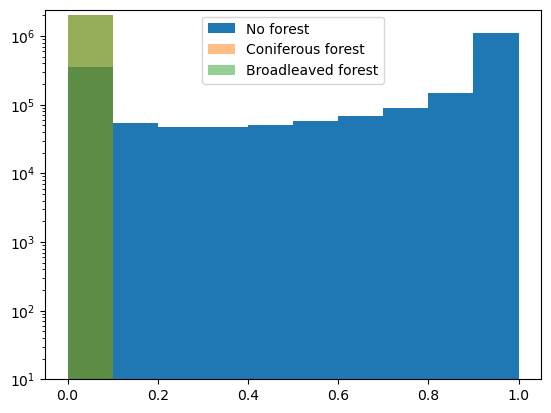

In [26]:
import matplotlib.pyplot as plt
counts1, bins1, patches1 = plt.hist(no_forest.values.flatten(), label="No forest")
plt.hist(coniferous_forest.values.flatten(), bins=bins1, alpha=0.5, label='Coniferous forest')
plt.hist(broadleaved_forest.values.flatten(), bins=bins1, alpha=0.5, label='Broadleaved forest')
plt.yscale("log")
plt.ylim(10)
plt.legend()
plt.show()

In [32]:
import rasterio
import numpy as np

def diagnose_vrt(vrt_path: str):
    """
    Opens a VRT or TIF file and prints critical metadata and pixel distributions 
    to diagnose masking and geographic alignment issues.
    """
    print(f"--- Diagnosing: {vrt_path} ---")
    
    with rasterio.open(vrt_path) as src:
        # 1. Check the Shape and Bands
        print(f"Shape (Bands, Rows, Cols): {src.count}, {src.height}, {src.width}")
        print(f"Data Type: {src.dtypes[0]}")
        print(f"NoData Value: {src.nodata}")
        
        # 2. Check the Geographic Bounding Box
        # Are we actually over Maasmechelen?
        print(f"\nCRS: {src.crs}")
        print(f"Bounds: {src.bounds}")
        
        # 3. Check for the RGB / Colormap Trap
        try:
            colormap = src.colormap(1)
            print("\nColormap detected! This is an indexed color image, not a raw categorical array.")
            # Print the first few color mappings just to see them
            for i in range(5):
                if i in colormap:
                    print(f"  Value {i} maps to RGB {colormap[i]}")
        except ValueError:
            print("\nNo colormap detected. This appears to be a standard data array.")

        # 4. Read the array and check the actual unique values
        print("\nReading Band 1 into memory to check unique pixel values...")
        # Note: For massive files this could spike RAM, but for a micro_lake it's perfectly safe
        data = src.read(1)
        
        unique_vals, counts = np.unique(data, return_counts=True)
        total_pixels = data.size
        
        print("\nPixel Value Distribution (Band 1):")
        for val, count in zip(unique_vals, counts):
            percentage = (count / total_pixels) * 100
            print(f"  Value: {val:3} | Count: {count:9} | Percentage: {percentage:>6.2f}%")

# --- Run the Diagnostic ---
# Replace this with the actual path from your logs
vrt_file = "./test_outputs_2/micro_lake/raw_downloads/EO_EEA_DAT_HRL_TCF/tif_files/Forest_Type_2018.vrt"
diagnose_vrt(vrt_file)

--- Diagnosing: ./test_outputs_2/micro_lake/raw_downloads/EO_EEA_DAT_HRL_TCF/tif_files/Forest_Type_2018.vrt ---
Shape (Bands, Rows, Cols): 1, 20000, 10000
Data Type: uint8
NoData Value: None

CRS: EPSG:3035
Bounds: BoundingBox(left=4000000.0, bottom=3000000.0, right=4100000.0, top=3200000.0)

Colormap detected! This is an indexed color image, not a raw categorical array.
  Value 0 maps to RGB (240, 240, 240, 255)
  Value 1 maps to RGB (70, 158, 74, 255)
  Value 2 maps to RGB (28, 92, 36, 255)
  Value 3 maps to RGB (0, 0, 0, 255)
  Value 4 maps to RGB (0, 0, 0, 255)

Reading Band 1 into memory to check unique pixel values...

Pixel Value Distribution (Band 1):
  Value:   0 | Count: 140753182 | Percentage:  70.38%
  Value:   1 | Count:        66 | Percentage:   0.00%
  Value:   2 | Count:        62 | Percentage:   0.00%
  Value:   3 | Count:        77 | Percentage:   0.00%
  Value:   4 | Count:        70 | Percentage:   0.00%
  Value:  16 | Count:         1 | Percentage:   0.00%
  Value:

In [4]:
def fetch_wekeo_dataset_versions(recipe: dict, hda_client) -> dict:
    """Scans the recipe for WEkEO datasets and fetches their current upstream metadata."""
    source_versions = {}
    
    wekeo_datasets = recipe.get('sources', {}).get('wekeo', {}).get('datasets', {})
    
    for dataset_cat, dataset_info in wekeo_datasets.items():
        if not dataset_info.get('include', False):
            continue
            
        # Reconstruct the WEkEO ID (Assuming standard HRL formatting for this example)
        dataset_id = f"EO:EEA:DAT:HRL:{dataset_cat}"
        
        try:
            meta = hda_client.dataset(dataset_id)
            source_versions[dataset_id] = {
                "title": meta.get("title", "Unknown"),
                # Fallbacks for how different Copernicus agencies label their versions
                "version": meta.get("version") or meta.get("processing_baseline") or "Latest",
                "revision_date": meta.get("revision_date", "Unknown")
            }
        except Exception as e:
            source_versions[dataset_id] = f"Failed to fetch metadata: {e}"
            
    return source_versions

In [6]:
from hda import Client
# Initialize the WEkEO HDA client 
# (It automatically looks for your API credentials in a hidden ~/.hdarc file)
c = Client()
fetch_wekeo_dataset_versions(microlake_recipe, c)

{'EO:EEA:DAT:HRL:GRA': {'title': 'Unknown',
  'version': 'Latest',
  'revision_date': 'Unknown'},
 'EO:EEA:DAT:HRL:TCF': {'title': 'Unknown',
  'version': 'Latest',
  'revision_date': 'Unknown'}}

In [7]:
from hda import Client
import json

dataset_id = "EO:EEA:DAT:HRL:GRA"

# Fetch the raw metadata object
try:
    meta = c.dataset(dataset_id)
    # Dump the entire dictionary to the console nicely formatted
    print(json.dumps(meta, indent=4, default=str))
except Exception as e:
    print(f"Failed to fetch: {e}")

{
    "dataset_id": "EO:EEA:DAT:HRL:GRA",
    "terms": [
        "Copernicus_Land_Monitoring_Service_Data_Policy"
    ],
    "roles": [],
    "multisearch": false,
    "stac_items": false,
    "status": "enabled",
    "metadata": {
        "abstract": "High Resolution Layer Grasslands products map the location and size of permanent and temporary grasslands, in addition to providing information on mowing events across the EEA38. These products are all offered at high resolution and include annual status layers. Change layers are also available, showing grassland vegetation gain and loss in 3-yearly updates. The products are designed to be used by researchers, policymakers, farmers, or anyone else who stands to benefit from monitoring the state of grassland ecosystems in Europe. Key application areas range from implementation or monitoring of various European Union (EU) policies such as the Habitats Directive or the Common Agriculture Policy, to contributing to research on how climate ch

In [8]:
def fetch_wekeo_dataset_versions(recipe: dict, hda_client) -> dict:
    """
    Scans the recipe for WEkEO datasets and extracts the deeply nested 
    EEA/Copernicus publication dates, catalogue identifiers, and management 
    plan versions to ensure strict source provenance.
    """
    source_versions = {}
    
    wekeo_datasets = recipe.get('sources', {}).get('wekeo', {}).get('datasets', {})
    
    for dataset_cat, dataset_info in wekeo_datasets.items():
        if not dataset_info.get('include', False):
            continue
            
        dataset_id = f"EO:EEA:DAT:HRL:{dataset_cat}"
        
        try:
            # Fetch the raw JSON payload from the API
            raw_meta = hda_client.dataset(dataset_id)
            meta_block = raw_meta.get("metadata", {})
            
            # 1. Extract internal EEA processing baselines hidden in keywords
            eea_baselines = []
            for kw_obj in meta_block.get("keywordsAsObjects", []):
                if kw_obj.get("thesaurus") == "EEA Management Plan":
                    keywords = kw_obj.get("keyword", [])
                    if isinstance(keywords, list):
                        eea_baselines.extend(keywords)
                    else:
                        eea_baselines.append(keywords)
            
            # 2. Package the exact source provenance
            source_versions[dataset_id] = {
                "title": meta_block.get("datasetTitle", raw_meta.get("title", "Unknown Title")),
                "publication_date": meta_block.get("publication_date", "Unknown Date"),
                "eea_catalogue_id": meta_block.get("ident_identifier", []),
                "eea_management_baselines": eea_baselines,
                "api_last_sync": raw_meta.get("last_sync", "Unknown")
            }
            
        except Exception as e:
            source_versions[dataset_id] = {"error": f"Failed to fetch metadata: {e}"}
            
    return source_versions

In [9]:
fetch_wekeo_dataset_versions(microlake_recipe, c)

{'EO:EEA:DAT:HRL:GRA': {'title': 'HRL Grasslands',
  'publication_date': '2024-12-01',
  'eea_catalogue_id': ['DAT-201-en', 'copernicus_hrl-grasslands_s'],
  'eea_management_baselines': ['2018 3.6.1', '2024 6.5.24'],
  'api_last_sync': '2026-04-20T00:00:13.095000'},
 'EO:EEA:DAT:HRL:TCF': {'title': 'HRL Tree Cover and Forests',
  'publication_date': '2024-12-01',
  'eea_catalogue_id': ['DAT-189-en',
   'copernicus_hlr-tree-cover-and-forests_s'],
  'eea_management_baselines': ['2018 3.6.1', '2024 6.5.24'],
  'api_last_sync': '2026-04-20T00:00:13.095000'}}